# PMOIRED tutorial: advanced binary fitting using GRAVITY spectro-interferometry

Interferometry with high spectral resolution can be used to analyze interferometry across line profiles (spectro-interferometry). This can be advantageous for binary fitting if one of the components has a much stronger absorption/emission in that line compared to the other. 

In this short example, the case of GRAVITY data of the Be + bloated pre-subdwarf binary HR 6819 is shown (Klement+ 2025, 2025A&A...694A.208K). The two components have similar brightness, but very small separation of ~1 mas, which is close to the resolution limit in VLTI Large configuration. The binary proved difficult to resolve using continuum data only, so we zoomed into the Br-gamma line, in which the primary Be star shows strong double-peaked emission from its circumstellar disk, while the secondary does not. The large difference in the line profiles increases the contrast compared to the continuum, and the binary can be resolved much more easily. *You can measure radial velocities and astrometry at the same time!*

This notebook will briefly go through the following steps:
- Displaying high spectral resolution GRAVITY data zoomed into the Br-gamma hydrogen line
- Fitting a simple analytic line profile + companion model
- Fitting a Keplerian-disk + companion model
- Isolating the Keplerian signal from the companion signal

*Keplerian model is covered in PMOIRED example #4, while PMOIRED example #5 covers binary fitting using absorption lines.*

PMOIRED version: 1.3.11
Using file: data/HR6819/2023Jul17_SCI_HR6819_EP4_SINGLE_SCI_VIS_CALIBRATED.fits
loadOI: loading data/HR6819/2023Jul17_SCI_HR6819_EP4_SINGLE_SCI_VIS_CALIBRATED.fits
  > insname: "GRAVITY_SC" targname: "HR_6819" pipeline: "GRAVITY pipeline 1.6.6"
  > MJD: (2,) [60143.0605..60143.0698] ~2023-07-18T01:33:45.709
  > A0-G1-J2-K0 | WL: (1628,) [ 1.97 .. 2.4 ] um (R~4134 P~8268) {'FLUX': 4, 'T3': 4, 'VIS': 6, 'VIS2': 6} | TELL: True pwv=2.57mm


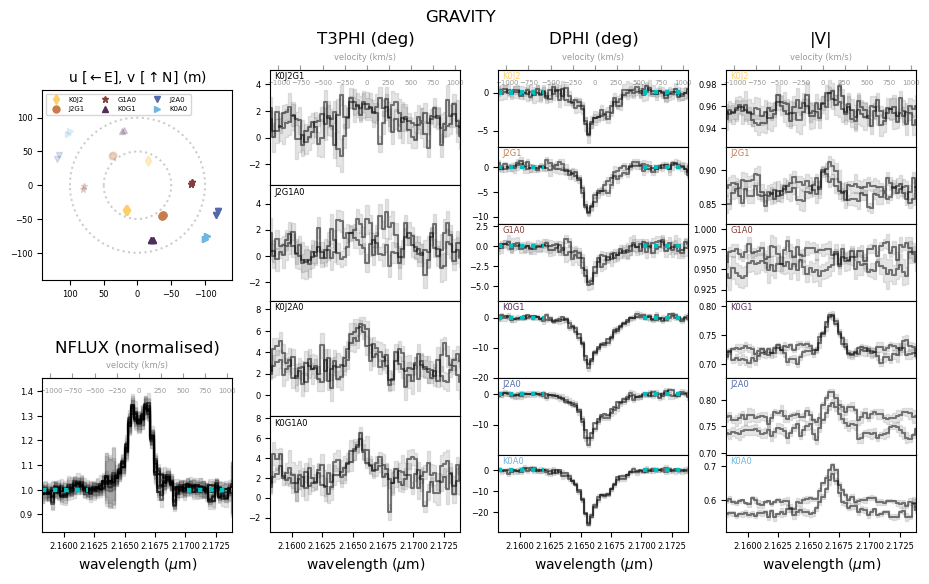

In [1]:
# -- uncomment for interactive plots
# %matplotlib widget
from glob import glob
import numpy as np
import pmoired
print('PMOIRED version:', pmoired.__version__)

BrG = 2.1661178
files = sorted(glob('data/HR6819/*.fits'))
print('Using file:', files[0])

oi = pmoired.OI(
    files[0],
    verbose=True,
    insname='GRAVITY_SC',
    binning=None,
    useTelluricsWl=True,
)

fit = {
    'obs': ['NFLUX', 'T3PHI', 'DPHI', '|V|'],
    'wl ranges': [(BrG - 0.008, BrG + 0.008)],
    'continuum ranges': [(2.1, 2.162), (2.170, 2.4)],
}
oi.setupFit(fit, update=False, debug=False)

oi.show(spectro=True, showUV=True, vWl0=BrG, bckgGrid=False, fig=1)


**Use a simple UD (Be star) + line profile (Be disk) + UD (companion) model.** *This was the model used in the initial discovery paper (Frost+ 2022, 2022A&A...659L...3F).*

[dpfit] 6 FITTED parameters: ['Be,line_1_f', 'Be,line_1_lorentzian', 'RV_Be', 'dDEC', 'dRA', 'f_pre_sd']
[dpfit] epsfcn= 1e-08 ftol= 1e-05
[dpfit] using scipy.optimize.leastsq
[dpfit] Wed Mar 11 14:50:05 2026 001/000 CHI2: 5.1998e+00|
[dpfit] Both actual and predicted relative reductions in the sum of squares  are at most 0.000010
[dpfit] 22 function calls ( 31.42 ms on average)
# -- degrees of freedom: 2040
# -- reduced chi2: 4.931511787504892
{'Be,line_1_f':         0.3921, # +/- 0.0051
'Be,line_1_lorentzian':2.111, # +/- 0.041
'RV_Be':               4.51, # +/- 1.82
'dDEC':                1.2344, # +/- 0.0033
'dRA':                 0.4201, # +/- 0.0027
'f_pre_sd':            0.4575, # +/- 0.0027
'Be,f':                '1.0 - $f_pre_sd',
'Be,line_1_wl0':       '2.1661178*(1+$RV_Be/2.998e5)',
'Be,ud':               0.1,
'pre-sd,f':            '$f_pre_sd',
'pre-sd,ud':           0.1,
'pre-sd,x':            '$dRA',
'pre-sd,y':            '$dDEC',
}

Correlations (%)  >=95 >=90 >=80 >=60

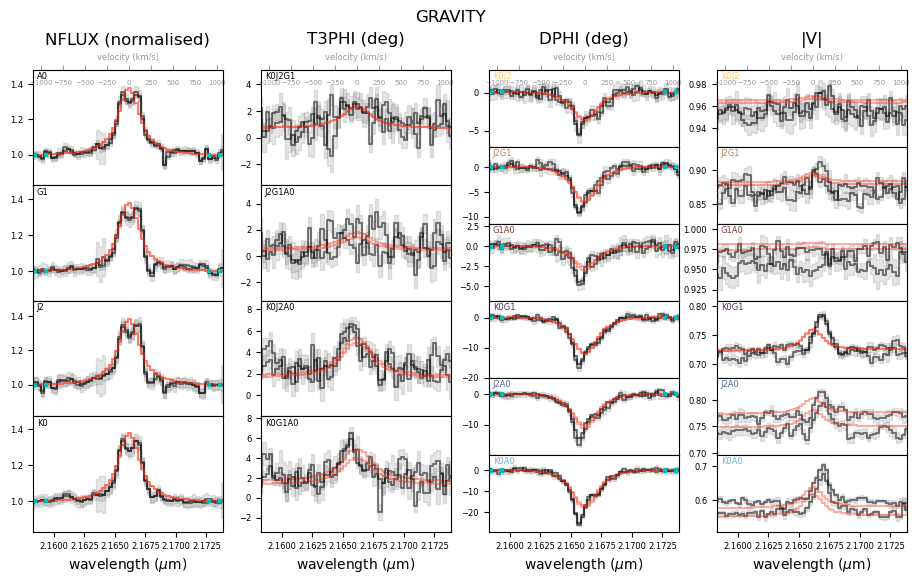

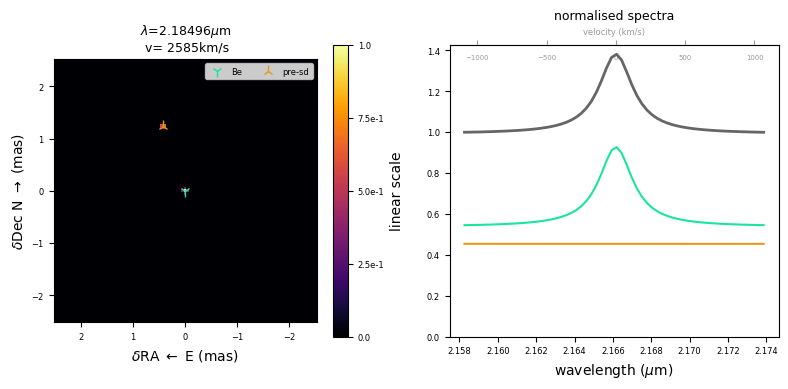

In [ ]:
model = {
    # -- shared helper parameters
    'RV_Be': -8.0,
    'f_pre_sd': 0.44,
    'dRA': 0.418,
    'dDEC': 1.238,
    # -- Be primary with simple analytic Br-gamma line profile
    'Be,ud': 0.1,
    'Be,f': '1.0 - $f_pre_sd',
    'Be,line_1_f': 0.39,
    'Be,line_1_lorentzian': 2.1,
    'Be,line_1_wl0': '2.1661178*(1+$RV_Be/2.998e5)',
    # -- pre-sdOB companion (flux and astrometry)
    'pre-sd,ud': 0.1,
    'pre-sd,f': '$f_pre_sd',
    'pre-sd,x': '$dRA',
    'pre-sd,y': '$dDEC',
}

do_not_fit = ['Be,f', 'Be,ud', 'pre-sd,ud']
oi.doFit(
    model,
    doNotFit=do_not_fit,
    verbose=2,
    maxfev=10000,
    ftol=1e-5,
    epsfcn=1e-8,
)

model_line = oi.bestfit['best'].copy()

oi.show(model=model_line, spectro=True, showUV=False, imFov=5, vWl0=BrG, bckgGrid=False, fig=2)

**Introduce a keplerian disk model for the Be star disk instead of a simple line profile**

[dpfit] 9 FITTED parameters: ['EW_brg', 'FWHM_brg', 'Incl_disk', 'PA_disk', 'RV_Be', 'Vorb_SINI_Be', 'dDEC', 'dRA', 'f_pre-sd']
[dpfit] epsfcn= 1e-08 ftol= 1e-05
[dpfit] using scipy.optimize.leastsq
[dpfit] Wed Mar 11 14:50:26 2026 001/000 CHI2: 3.4656e+00|
[dpfit] Wed Mar 11 14:50:36 2026 026/002 CHI2: 2.9555e+00|
[dpfit] Wed Mar 11 14:50:46 2026 060/006 CHI2: 2.8034e+00|
[dpfit] Both actual and predicted relative reductions in the sum of squares  are at most 0.000010
[dpfit] 83 function calls ( 328.1 ms on average)
# -- degrees of freedom: 2038
# -- reduced chi2: 2.8031862299823183
{'EW_brg':            0.8519, # +/- 0.0070
'FWHM_brg':          0.430, # +/- 0.016
'Incl_disk':         24.55, # +/- 0.88
'PA_disk':           28.60, # +/- 3.16
'RV_Be':             20.20, # +/- 1.02
'Vorb_SINI_Be':      263.77, # +/- 4.94
'dDEC':              1.2365, # +/- 0.0025
'dRA':               0.4188, # +/- 0.0021
'f_pre-sd':          0.4406, # +/- 0.0020
'Be,f':              '1.0 - $pre-sd,f',
'Be

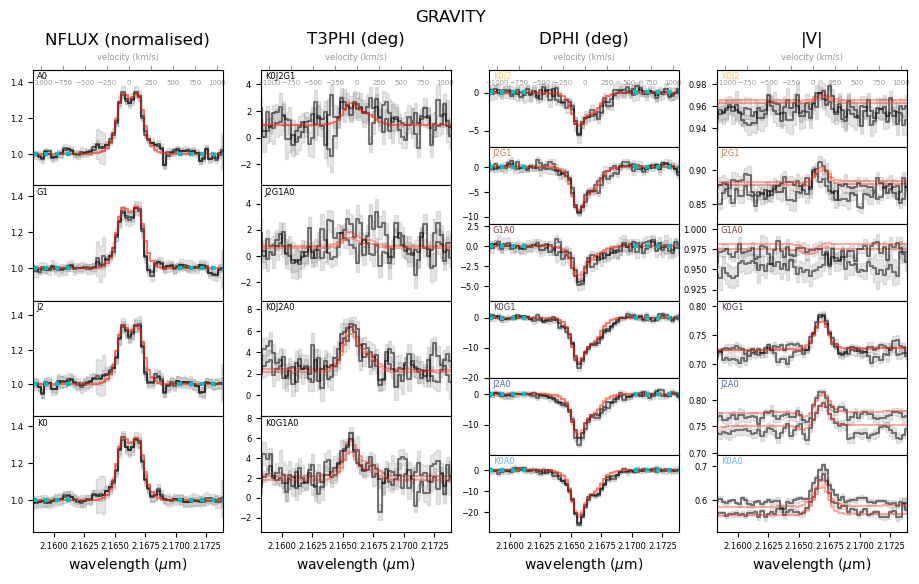

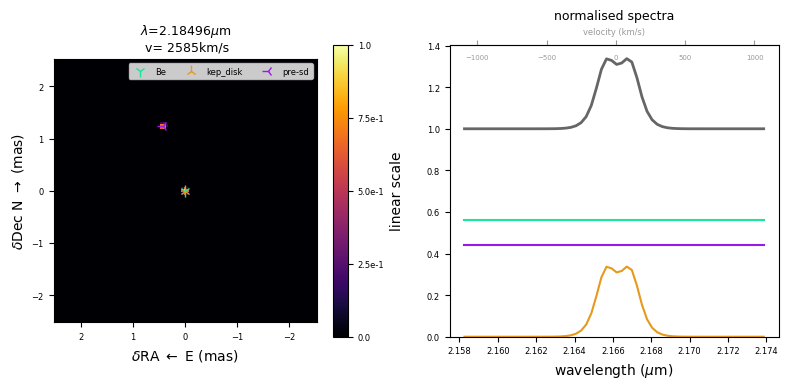

In [ ]:
model = {
    # -- shared helper parameters
    'RV_Be': 4.5,
    # -- Be primary photosphere + continuum coupling
    'Be_UD': 0.12,
    'Be,ud': '$Be_UD',
    'Be,f': '1.0 - $pre-sd,f',
    # -- pre-sdOB companion (flux + astrometry)
    'f_pre-sd': 0.44,
    'pre-sd,f': '$f_pre-sd',
    'dRA': 0.42,
    'dDEC': 1.23,
    'pre-sd,x': '$dRA',
    'pre-sd,y': '$dDEC',
    'pre-sd,ud': 0.12,
    # -- Keplerian Br-gamma disk around Be star
    'Incl_disk': 39.0,
    'kep_disk,incl': '$Incl_disk',
    'EW_brg': 0.84,
    'kep_disk,line_EW': '$EW_brg',
    'FWHM_brg': 0.38,
    'kep_disk,line_fwhm': '$FWHM_brg',
    'PA_disk': 30.0,
    'kep_disk,projang': '$PA_disk',
    'Vorb_SINI_Be': 240.0,
    'kep_disk,Vin': '$Vorb_SINI_Be/np.sin(np.radians($kep_disk,incl))',
    'kep_disk,beta': -0.5,
    'kep_disk,diamin': '$Be,ud',
    'kep_disk,line_wl0': '2.1661178*(1+$RV_Be/2.998e5)',
}

do_not_fit = ['Be,f', 'Be_UD', 'kep_disk,beta', 'pre-sd,ud']
oi.doFit(
    model,
    doNotFit=do_not_fit,
    verbose=2,
    maxfev=10000,
    ftol=1e-5,
    epsfcn=1e-8,
)

model_kep = oi.bestfit['best'].copy()

oi.show(model=model_kep, spectro=True, showUV=False, imFov=5, vWl0=BrG, bckgGrid=False, fig=3)


**Display the keplerian disk signal with the companion removed**

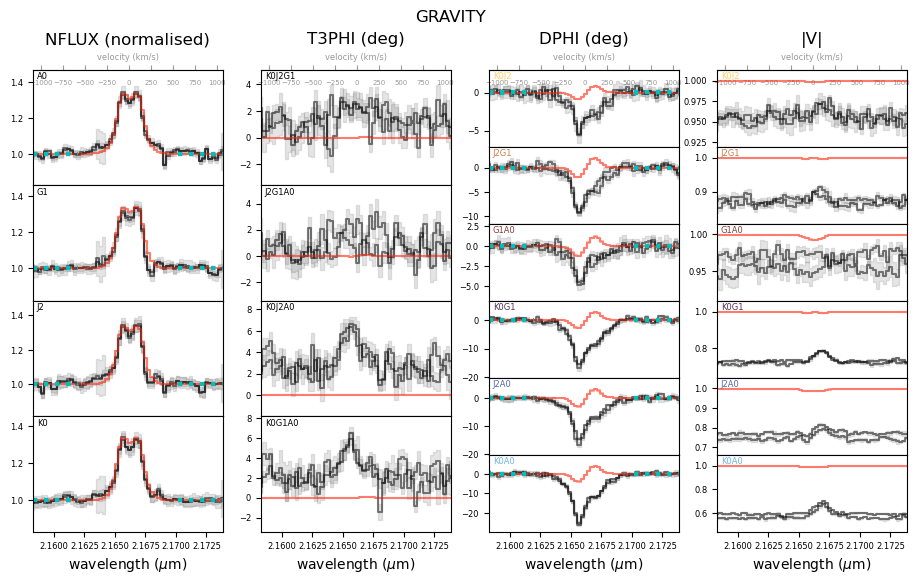

In [5]:
# -- Keplerian-only model (remove companion)
model_kep_only = {k: v for k, v in model_kep.items() if not k.startswith('pre-sd,')}
model_kep_only['Be,f'] = 1.0

oi.show(
    model=model_kep_only,
    spectro=True,
    showUV=False,
    vWl0=BrG,
    bckgGrid=False,
    fig=4,
)